Bölüm 2: Python ile Sayısal (Numerical) MLE

In [1]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

# Gözlemlenen Trafik Verisi (1 dakikada geçen araç sayısı)
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])


def negative_log_likelihood(lam, data):
 """
 Poisson dağilimi için Negatif Log-Likelihood hesaplar.
 İpucu: log(k!) terimi optimizasyon sirasinda sabit
 olduğu için ihmal edilebilir.
 """
 n = len(data)
 # TODO: Log-likelihood formülünü (negatif olarak) buraya yazın
 # NLL(negative log likelihood) = n * lambda - ln(lambda) * sum(k_i)
 nll = (n * lam) - (np.log(lam) * np.sum(data))

 # nll = - (toplam log-likelihood)
 return nll


# Başlangıç tahmini
initial_guess = 1.0

# Optimizasyon: NLL'yi minimize etmek, Likelihood'u maximize etmektir.
result = opt.minimize(negative_log_likelihood, initial_guess, args=(traffic_data,), bounds=[(0.001, None)])

print(f"Sayisal Tahmin (MLE lambda): {result.x[0]}")
print(f"Analitik Tahmin (Ortalama): {np.mean(traffic_data)}")

Sayisal Tahmin (MLE lambda): 12.1428566075515
Analitik Tahmin (Ortalama): 12.142857142857142


Bölüm 3: Model Karşılaştırma ve Görselleştirme

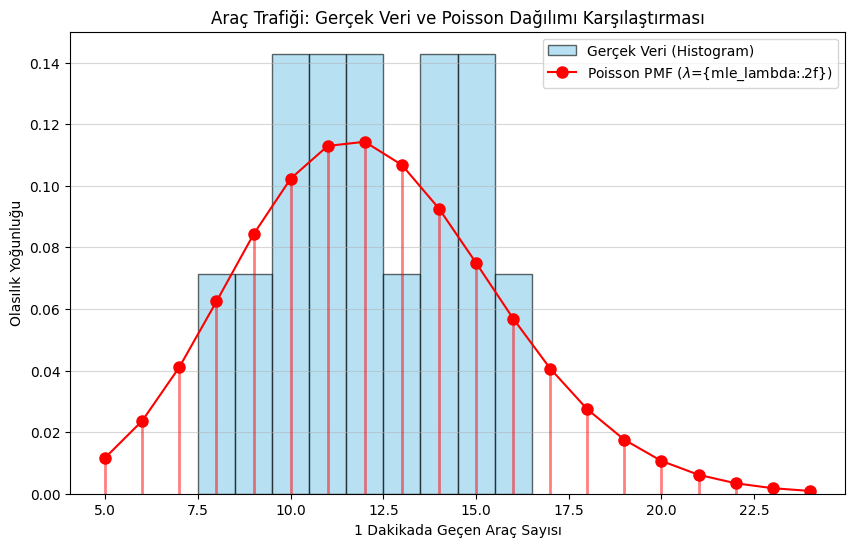

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Bölüm 2'deki gerçek trafik verimiz
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

# MLE ile bulduğumuz lambda değeri
mle_lambda = np.mean(traffic_data)

# X ekseni: Olası araç sayıları
x = np.arange(5, 25)

# Teorik Poisson PMF (Olasılık Kütle Fonksiyonu) hesaplaması
pmf_values = poisson.pmf(x, mle_lambda)


plt.figure(figsize=(10, 6))

# 1. Gerçek verinin histogramı
plt.hist(traffic_data, bins=np.arange(7.5, 17.5, 1), density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Gerçek Veri (Histogram)')

# 2. Teorik Poisson PMF Grafiği
plt.plot(x, pmf_values, 'ro-', ms=8, label=r'Poisson PMF ($\lambda$={mle_lambda:.2f})')
plt.vlines(x, 0, pmf_values, colors='r', lw=2, alpha=0.5)

plt.title('Araç Trafiği: Gerçek Veri ve Poisson Dağılımı Karşılaştırması')
plt.xlabel('1 Dakikada Geçen Araç Sayısı')
plt.ylabel('Olasılık Yoğunluğu')
plt.legend()
plt.grid(axis='y', alpha=0.5)

plt.show()